<a href="https://colab.research.google.com/github/aoleonela-repositorio/Procesamiento_Img_Dig_TP3/blob/main/TP3_TPDI_Azcona_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##TRABAJO PRÁCTICO N°3

##UMBRALIZACIÓN

#Definición

La umbralización consiste en transformar una imagen en escala de grises en una imagen binaria (blanco y negro) aplicando un valor de umbral.
- Los píxeles con intensidad mayor al umbral se convierten en blancos (1).

- Los píxeles con intensidad menor o igual al umbral se convierten en negros (0).

Formalmente:

g(x,y)=\left\{ \, \begin{array}{ll}\textstyle 1&\textstyle \mathrm{si\  }f(x,y)>T\\ \textstyle 0&\textstyle \mathrm{si\  }f(x,y)\leq T\end{array}\right.

donde:
- f(x,y) es la intensidad del píxel en la posición (x,y).
- T es el valor de umbral.
- g(x,y) es la nueva imagen binaria.




El valor del umbral es el parámetro clave en la umbralización, y su elección depende de cómo querés separar el objeto del fondo en la imagen. Con motivo de reducir el ruido y optimizar el procesamiento de la imágen, se debe aplicar previamente un filtro gaussiano.

#Filtro Gaussiano

El filtro gaussiano es una técnica de procesamiento de imágenes que se utiliza para suavizar o desenfocar una imagen, reduciendo el ruido y los detalles finos. Se basa en la función matemática de la distribución gaussiana (también llamada campana de Gauss).

El filtro aplica una convolución de la imagen con una máscara (kernel) cuyos valores siguen una distribución gaussiana:
G(x,y)=\frac{1}{2\pi \sigma ^2}e^{-\frac{x^2+y^2}{2\sigma ^2}}
- x,y: coordenadas dentro del kernel.
- \sigma : desviación estándar, controla el grado de suavizado.

• 	El kernel tiene valores más altos en el centro y más bajos en los bordes, lo que da más peso a los píxeles cercanos.


Se usa para:

- Reducir ruido: elimina variaciones pequeñas que pueden confundirse con detalles importantes.
- Suavizar bordes: hace que las transiciones sean más suaves.
- Preprocesamiento: se usa antes de aplicar técnicas como umbralización, detección de bordes o segmentación.
Ejemplo: si una imagen tiene manchas o puntos de ruido, el filtro gaussiano los difumina para que no afecten el análisis.





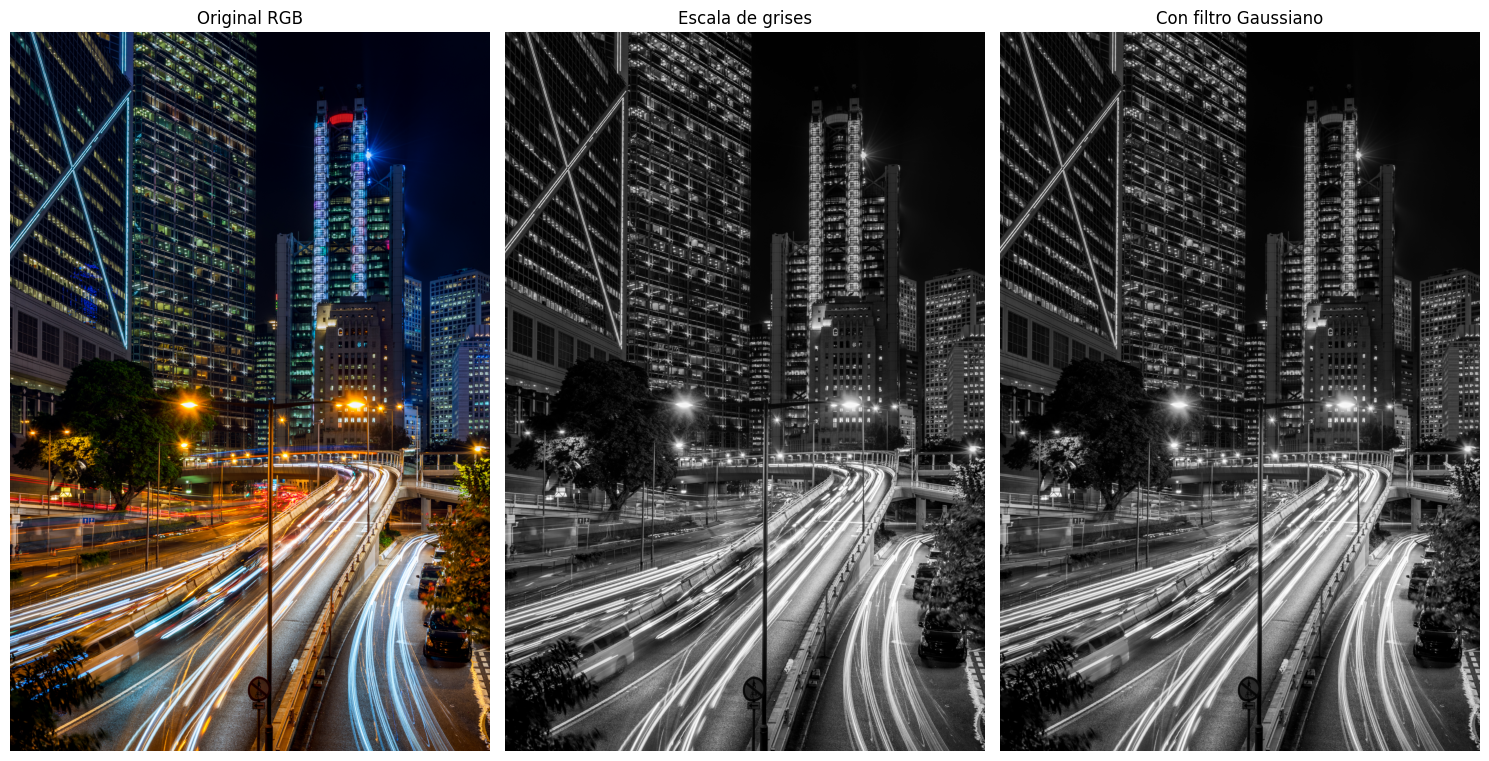

In [ ]:
# IMPORTAR LIBRERÍAS NECESARIAS

# Para procesamiento de imagenes
import cv2
# Para mostrar imágenes y gráficos
import matplotlib.pyplot as plt
# Para operaciones matriciales
import numpy as np
# Para hacer solicitudes HTTP a webs o APIs
import requests

# IMPORTAR IMÁGEN
# URL cruda de la imagen en GitHub
url = 'https://raw.githubusercontent.com/aoleonela-repositorio/Procesamiento_Img_Dig_TP3/main/hong-kong-traffic-view.jpg'

# Hacer la solicitud GET
response = requests.get(url)

# Convertir el contenido en un array de bytes con numpy
img_array = np.asarray(bytearray(response.content), dtype=np.uint8)

# 4. Decodificar la imagen con OpenCV
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# Convertir a RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convertir a imagen con escala de grises
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Aplicar filtro gaussiano con kernel de 5x5
gauss = cv2.GaussianBlur(img_gray, (5, 5), 0) # El cero indica que OpenCV calculará automaticamente la desviación estándar.

# Mostrar resultados
plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Escala de grises')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gauss, cmap='gray')
plt.title('Con filtro Gaussiano')
plt.axis('off')

plt.tight_layout()
plt.show()

# Casos de umbralización



In [ ]:
# 2. Umbralización simple
# Separa objetos claros de fondos oscuros en imágenes simples.
ret, simple = cv2.threshold(gauss, 127, 255, cv2.THRESH_BINARY)

# 127= umbral designado
# 255= valor máximo que se asigna a los píxeles que superan el umbral
# cv2.THRESH_BINARY= convierte los píxeles >127 en 255 (blanco) y ≤127 en 0 (negro)

# 3. Umbralización inversa
# útil cuando el objeto es oscuro y el fondo claro
ret, inversa = cv2.threshold(gauss, 127, 255, cv2.THRESH_BINARY_INV)
#Igual que la anterior, pero invertida: píxeles >127 → 0 (negro), píxeles ≤127 → 255 (blanco)

# 4. Umbralización adaptativa
# El umbral no es fijo, se calcula en función de la vecindad local
# Puede usarse para manejar imágenes con iluminación irregular (ejemplo: documentos escaneados con sombras)
adaptativa = cv2.adaptiveThreshold(gauss, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
# 255: valor máximo asignado
# cv2.ADAPTIVE_THRESH_MEAN_C: el umbral se calcula como la media de los valores vecinos menos una constante
# 11: tamaño del bloque (vecindad)
# 2: constante que se resta

# 5. Método de Otsu (umbral automático)
# Es una segmentación automática cuando no sabemos cuál es el mejor umbral.
ret, otsu = cv2.threshold(gauss, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# 0: se ignora porque Otsu calcula el umbral óptimo.
# cv2.THRESH_OTSU: busca el valor que maximiza la separación entre clases de píxeles

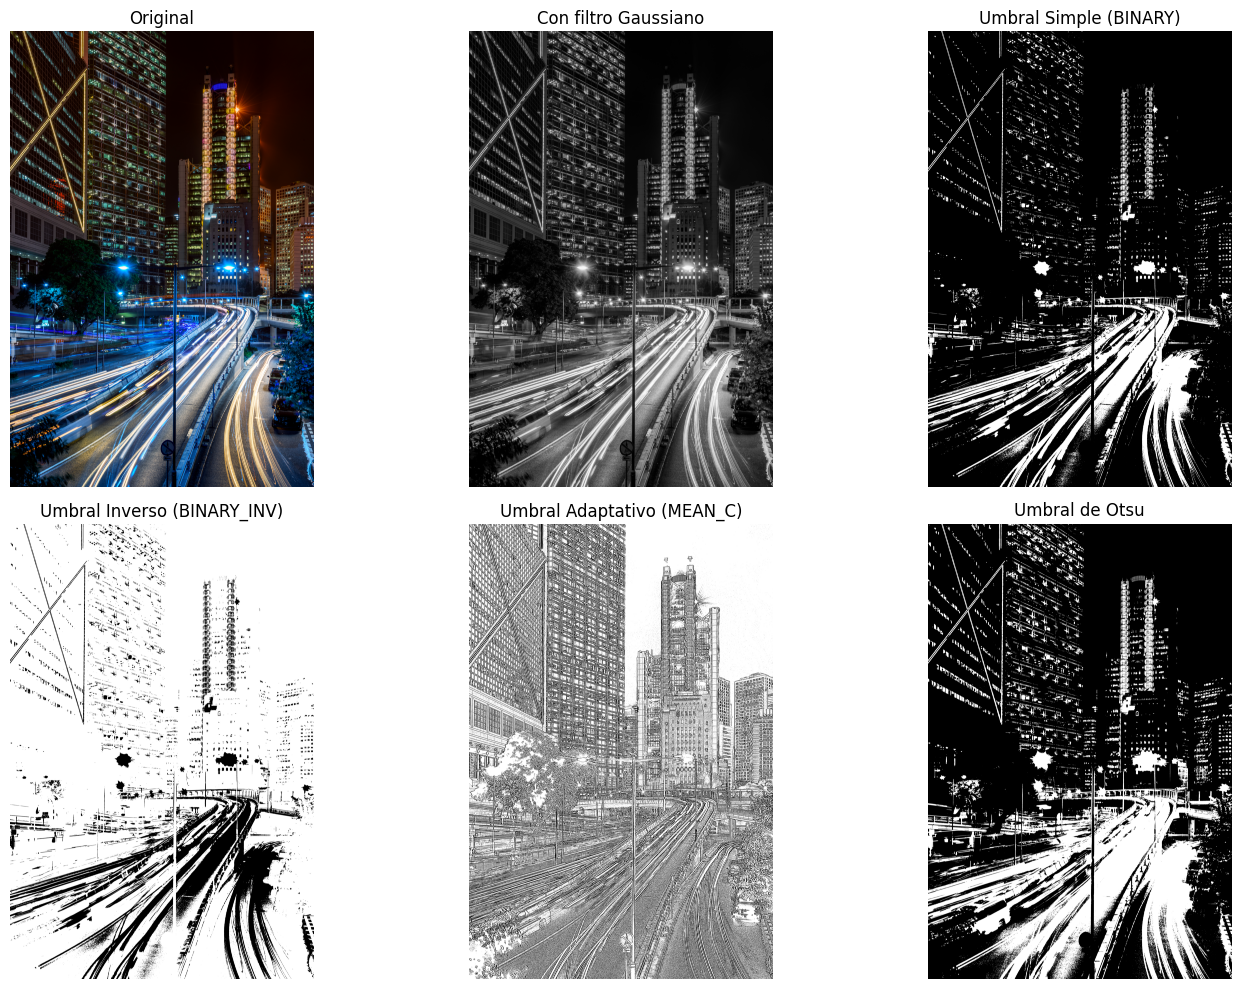

In [ ]:
# 6. Mostrar resultados usando matplotlib para ver todas las imágenes
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(gauss, cmap='gray')
plt.title('Con filtro Gaussiano')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(simple, cmap='gray')
plt.title('Umbral Simple (BINARY)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(inversa, cmap='gray')
plt.title('Umbral Inverso (BINARY_INV)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(adaptativa, cmap='gray')
plt.title('Umbral Adaptativo (MEAN_C)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(otsu, cmap='gray')
plt.title("Umbral de Otsu")
plt.axis('off')

plt.tight_layout()
plt.show()

APLICACION DE UMBRALES


#Criterios para determinar el umbral

1. 	Umbral fijo (manual)

Se elige un valor  de manera arbitraria o experimental. Ejemplo: si la imagen tiene fondo oscuro y objeto claro, como un texto negro sobre fondo blanco, se puede fijar  (en una escala de 0–255).
Propósito: rápido y simple, útil en imágenes homogéneas y bien iluminadas.


2. 	Histograma de intensidades
• 	Se analiza el histograma de la imagen (distribución de valores de gris). Si hay dos picos bien definidos (bimodal), el umbral se coloca en el valle entre ellos. Por ejemplo, monedas sobre mesa oscura.
Propósito: separar claramente dos regiones (fondo vs objeto).


3. 	Método de Otsu (automático)
• 	Calcula el umbral óptimo que minimiza la varianza intra-clase y maximiza la varianza entre clases. Matemáticamente, busca el  que mejor separa los píxeles en dos grupos. Ejemplo, segmentación de células en microscopía.
• 	Propósito: segmentación robusta sin intervención manual.


4. 	Umbralización adaptativa (local)
• 	El umbral se calcula en función de la vecindad local de cada píxel (media o mediana de intensidades en la región). Ejemplo, Documentos escaneados con sombras.
• 	Propósito: útil en imágenes con iluminación no uniforme (ejemplo: documentos con sombras).


5. 	Basado en criterios estadísticos o heurísticos
• 	Se puede definir el umbral como la media o la mediana de intensidades, o en función de desviaciones estándar. Ejemplo, Preprocesamiento inicial en visión por computadora.
• 	Propósito: rápido y sencillo cuando no se requiere precisión extrema.




### **RUIDO**

En procesamiento de imágenes, el ruido es cualquier variación aleatoria o indeseada en los valores de los píxeles que altera la calidad visual o dificulta el análisis. Se comporta como una “interferencia” que se superpone a la información real de la imagen.  El ruido, afecta tareas como segmentación, detección de bordes o reconocimiento de objetos.  



## Tipos de ruido

- **Ruido Gaussiano**  
  Se distribuye siguiendo una curva normal (gaussiana). Aparece como pequeñas variaciones de intensidad en toda la imagen, típico en sensores digitales.  

- **Ruido de Sal y Pimienta**  
  Se manifiesta como puntos blancos y negros aislados. Suele deberse a errores de transmisión o píxeles defectuosos.  

- **Ruido Speckle (granulado)**  
  Común en imágenes médicas (ecografías). Se ve como un patrón granular que dificulta la interpretación.  

- **Ruido Poisson (fotónico)**  
  Relacionado con la naturaleza estadística de la luz. Se nota en imágenes con baja iluminación o capturadas con pocos fotones.  

---

**Ejemplo**:  
En una foto sacada con celular en condiciones de poca luz, se verá granulado en las zonas oscuras. Eso es ruido gaussiano.  
Si se transmite una imagen digital y aparecen puntos blancos/negros aislados, es ruido sal y pimienta.  


